In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from os import environ
import os
import os

ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixpoisson")
datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/wbic")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

dry = False # whether or not to save results

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixpoisson/wbic


In [3]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [4]:
# def find_truth_by_dsid(dsid: str):
#   dgp = dgps.query(f"dsid=='{dsid}'")
#   truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
#   return truth

In [5]:
wbic_df = pd.read_csv(f"{outputdir}/wbic_bias.csv")
wbic_df.head()

,dsid,regime,n,trial,wbic,afe0,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components
0,regular,50,50,0,148.380982,148.565676,1,1000,2500,0.0,0,0,[0],5,2
1,e-singular,50,50,0,139.051604,141.161511,1,1000,2500,0.0,0,0,[0],7,2
2,singular1,50,50,0,129.864095,128.380325,1,1000,2500,0.0,0,0,[0],8,2
3,singular2,50,50,0,112.492161,111.998226,1,1000,2500,0.0,0,0,[0],7,2
4,regular,50,50,0,149.435218,149.543682,1,1000,2500,0.0,0,0,[0],8,3


In [6]:
# Prep data
wbic_df['error'] = wbic_df['wbic'] - wbic_df['afe0']
wbic_df['Model'] = wbic_df['n_components'].map({2: 'K=2', 3: 'K=3', 5: 'K=5'})
wbic_df.head()

,dsid,regime,n,trial,wbic,afe0,chains,draws,tune,mean_divergences,total_divergences,max_divergences,divergences_per_chain,chain_tree_depth,n_components,error,Model
0,regular,50,50,0,148.380982,148.565676,1,1000,2500,0.0,0,0,[0],5,2,-0.184694,K=2
1,e-singular,50,50,0,139.051604,141.161511,1,1000,2500,0.0,0,0,[0],7,2,-2.109907,K=2
2,singular1,50,50,0,129.864095,128.380325,1,1000,2500,0.0,0,0,[0],8,2,1.483769,K=2
3,singular2,50,50,0,112.492161,111.998226,1,1000,2500,0.0,0,0,[0],7,2,0.493936,K=2
4,regular,50,50,0,149.435218,149.543682,1,1000,2500,0.0,0,0,[0],8,3,-0.108464,K=3


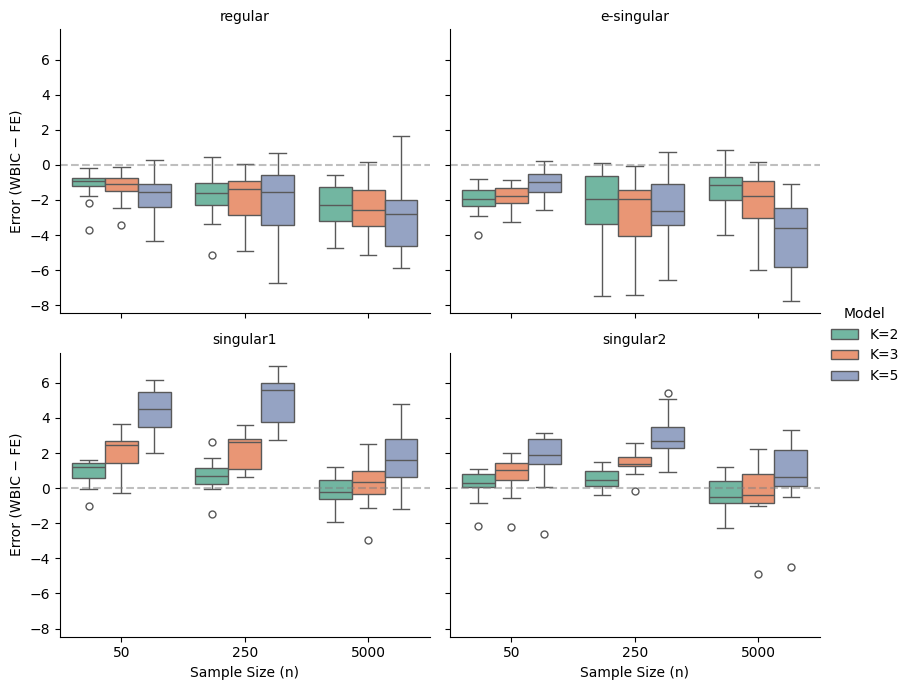

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot using catplot with shared y-axis
g = sns.catplot(
    data=wbic_df,
    x='n',
    y='error',
    hue='Model',
    col='dsid',
    kind='box',
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.2,
    palette='Set2'
)

# Add reference line at 0
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

g.set_axis_labels('Sample Size (n)', 'Error (WBIC − FE)')
g.set_titles(col_template='{col_name}')

# plt.tight_layout()
plt.savefig('wbic_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Estimated convergence rates (RMSE ~ n^(-α)):
      dsid Model     alpha  intercept  r_squared
e-singular   K=2  0.052288   1.144076   0.206919
e-singular   K=3 -0.052094   0.643060   0.188217
e-singular   K=5 -0.252991  -0.541865   0.845690
   regular   K=2 -0.122778  -0.020445   0.878062
   regular   K=3 -0.127792   0.027466   0.902141
   regular   K=5 -0.090108   0.517616   0.910794
 singular1   K=2  0.062404   0.432617   0.805847
 singular1   K=3  0.136635   1.485129   0.859852
 singular1   K=5  0.155065   2.269271   0.738738
 singular2   K=2 -0.032614  -0.344544   0.370929
 singular2   K=3 -0.041388   0.158819   0.574531
 singular2   K=5  0.036963   1.105262   0.121997


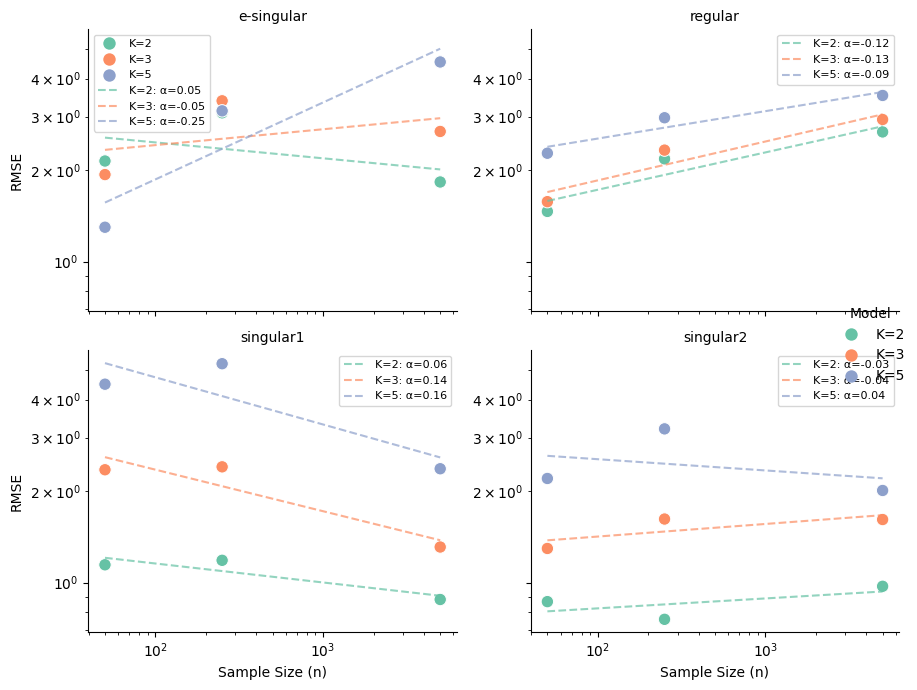


Convergence rates summary:
Model         K=2    K=3    K=5
dsid                           
e-singular  0.052 -0.052 -0.253
regular    -0.123 -0.128 -0.090
singular1   0.062  0.137  0.155
singular2  -0.033 -0.041  0.037


In [8]:
from scipy import stats

# Aggregate: RMSE per (dsid, n, model)
summary = wbic_df.groupby(['dsid', 'n', 'Model']).agg(
    rmse=('error', lambda x: np.sqrt(np.mean(x**2)))
).reset_index()

# Log transform for regression
summary['log_n'] = np.log(summary['n'])
summary['log_rmse'] = np.log(summary['rmse'])

# Fit convergence rate for each (dsid, Model)
def fit_rate(group):
    slope, intercept, r, p, se = stats.linregress(group['log_n'], group['log_rmse'])
    return pd.Series({
        'alpha': -slope,
        'intercept': intercept,
        'r_squared': r**2
    })

rates = summary.groupby(['dsid', 'Model']).apply(fit_rate).reset_index()
print("Estimated convergence rates (RMSE ~ n^(-α)):")
print(rates.to_string(index=False))

# Plot using relplot (continuous x-axis)
g = sns.relplot(
    data=summary,
    x='n',
    y='rmse',
    hue='Model',
    col='dsid',
    kind='scatter',
    col_wrap=2,
    height=3.5,
    aspect=1.2,
    palette='Set2',
    s=80
)

# Add fitted convergence lines
for ax, dsid in zip(g.axes.flat, summary['dsid'].unique()):
    subset = summary[summary['dsid'] == dsid]
    n_vals = sorted(subset['n'].unique())
    n_range = np.linspace(min(n_vals), max(n_vals), 100)
    
    for model, color in zip(['K=2', 'K=3', 'K=5'], sns.color_palette('Set2')):
        rate_row = rates[(rates['dsid'] == dsid) & (rates['Model'] == model)]
        if len(rate_row) == 0:
            continue
        alpha = rate_row['alpha'].values[0]
        intercept = rate_row['intercept'].values[0]
        
        fitted = np.exp(intercept) * n_range ** (-alpha)
        ax.plot(n_range, fitted, color=color, linestyle='--', alpha=0.7,
                label=f'{model}: α={alpha:.2f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(fontsize=8)

g.set_axis_labels('Sample Size (n)', 'RMSE')
g.set_titles(col_template='{col_name}')

plt.tight_layout()
plt.show()

print("\nConvergence rates summary:")
pivot = rates.pivot(index='dsid', columns='Model', values='alpha')
print(pivot.round(3))